<a href="https://colab.research.google.com/github/RAGHAVJINDGER/Exploratory-Data-Analysis/blob/main/Experiment6_01-09-26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [ ]:
print("Loading MNIST dataset...")

mnist = fetch_openml(
    'mnist_784',
    version=1,
    as_frame=False
)

X = mnist.data
y = mnist.target.astype(int)

print("Dataset loaded successfully!")

Loading MNIST dataset...
Dataset loaded successfully!


In [ ]:
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Number of classes:", len(np.unique(y)))
print("Classes:", np.unique(y))
print("Image dimensions: 28 x 28")

Number of samples: 70000
Number of features: 784
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
Image dimensions: 28 x 28


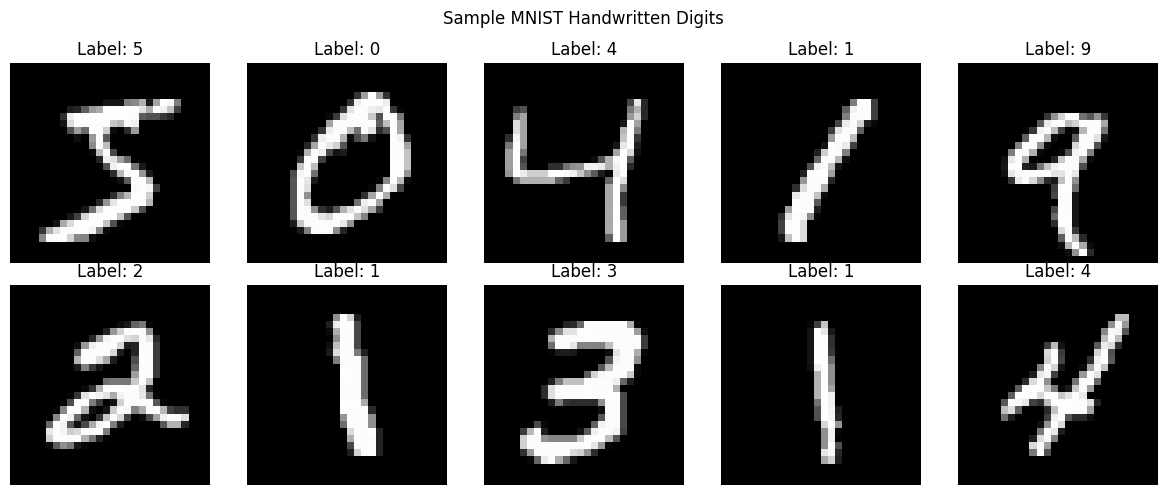

In [ ]:
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y[i]}")
    plt.axis('off')

plt.suptitle("Sample MNIST Handwritten Digits")
plt.tight_layout()
plt.show()

In [ ]:
X = X.astype('float32') / 255.0

print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [ ]:
print("Applying PCA...")

start_time = time.time()

pca = PCA(
    n_components=0.99,
    svd_solver='full'
)

X_pca = pca.fit_transform(X)

pca_time = time.time() - start_time

print("PCA completed!")
print("Original dimensions:", X.shape[1])
print("Dimensions after PCA:", X_pca.shape[1])
print("PCA computation time:", round(pca_time, 2), "seconds")

Applying PCA...
PCA completed!
Original dimensions: 784
Dimensions after PCA: 331
PCA computation time: 20.35 seconds


In [ ]:
explained_variance = pca.explained_variance_ratio_

print("Variance explained by first 10 components:\n")

for i in range(10):
    print(
        f"PC{i+1}: "
        f"{explained_variance[i] * 100:.4f}%"
    )

Variance explained by first 10 components:

PC1: 9.7461%
PC2: 7.1554%
PC3: 6.1495%
PC4: 5.4034%
PC5: 4.8889%
PC6: 4.3052%
PC7: 3.2783%
PC8: 2.8896%
PC9: 2.7584%
PC10: 2.3421%


In [ ]:
cumulative_variance = np.cumsum(explained_variance)

def components_for_variance(threshold):
    return np.argmax(cumulative_variance >= threshold) + 1

n_90 = components_for_variance(0.90)
n_95 = components_for_variance(0.95)
n_99 = components_for_variance(0.99)

print("Components required to retain:")
print("90% variance:", n_90)
print("95% variance:", n_95)
print("99% variance:", n_99)

Components required to retain:
90% variance: 87
95% variance: 154
99% variance: 331


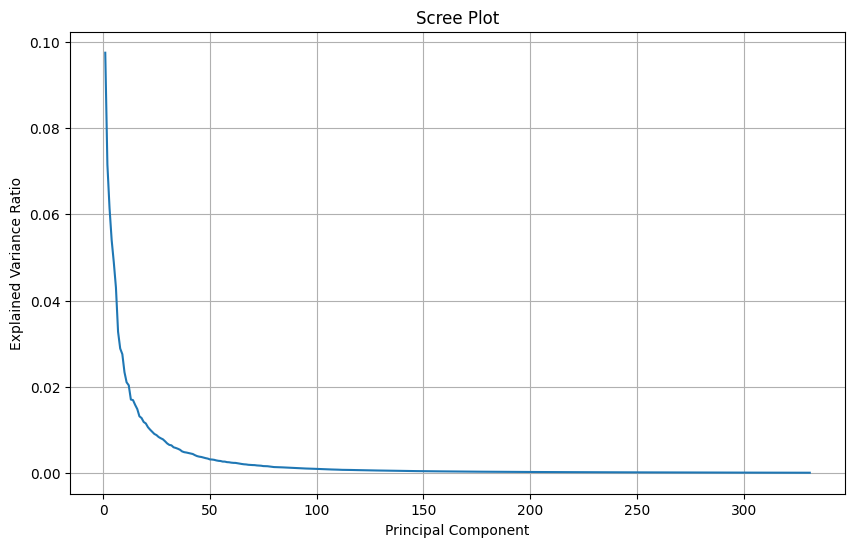

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid(True)

plt.show()

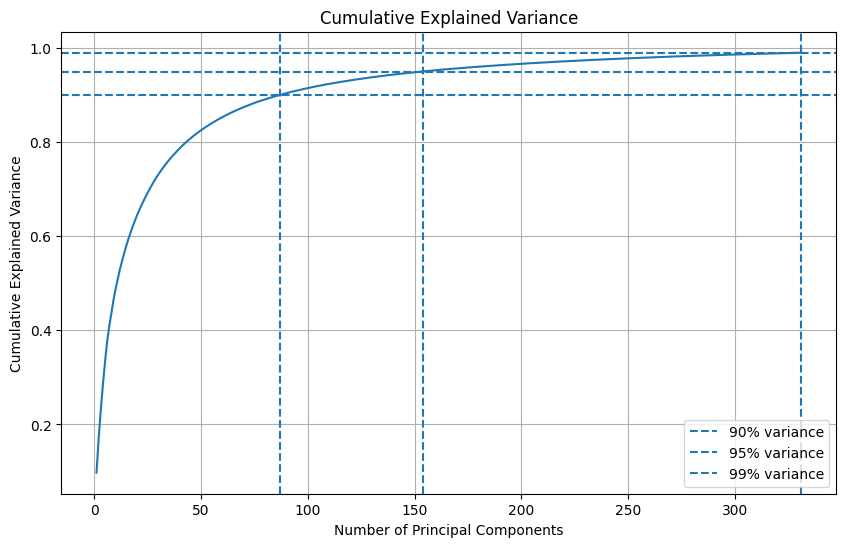

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance
)

plt.axhline(
    y=0.90,
    linestyle='--',
    label='90% variance'
)

plt.axhline(
    y=0.95,
    linestyle='--',
    label='95% variance'
)

plt.axhline(
    y=0.99,
    linestyle='--',
    label='99% variance'
)

plt.axvline(
    x=n_90,
    linestyle='--'
)

plt.axvline(
    x=n_95,
    linestyle='--'
)

plt.axvline(
    x=n_99,
    linestyle='--'
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
X_pca_2 = X_pca[:, :2]

print("Original shape:", X.shape)
print("2D PCA shape:", X_pca_2.shape)

Original shape: (70000, 784)
2D PCA shape: (70000, 2)


In [ ]:
X_pca_50 = X_pca[:, :50]

print("Original shape:", X.shape)
print("50D PCA shape:", X_pca_50.shape)

Original shape: (70000, 784)
50D PCA shape: (70000, 50)


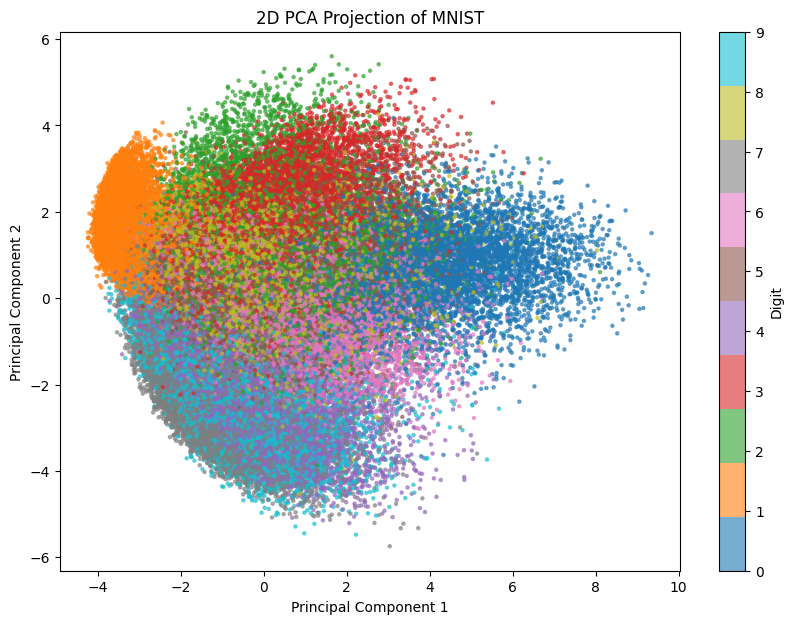

In [ ]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca_2[:, 0],
    X_pca_2[:, 1],
    c=y,
    cmap='tab10',
    s=5,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA Projection of MNIST")

plt.colorbar(scatter, label="Digit")

plt.show()

In [ ]:
TSNE_SAMPLES = 10000

np.random.seed(42)

indices = np.random.choice(
    len(X),
    TSNE_SAMPLES,
    replace=False
)

X_tsne_original = X[indices]
X_tsne_pca50 = X_pca_50[indices]
y_tsne = y[indices]

print("t-SNE samples:", len(indices))

t-SNE samples: 10000


In [ ]:
print("Running t-SNE on original 784-dimensional data...")

start_time = time.time()

tsne_original = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init='pca',
    learning_rate='auto'
)

X_tsne_original_2d = tsne_original.fit_transform(
    X_tsne_original
)

tsne_original_time = time.time() - start_time

print(
    "t-SNE completed in",
    round(tsne_original_time, 2),
    "seconds"
)

Running t-SNE on original 784-dimensional data...
t-SNE completed in 155.67 seconds


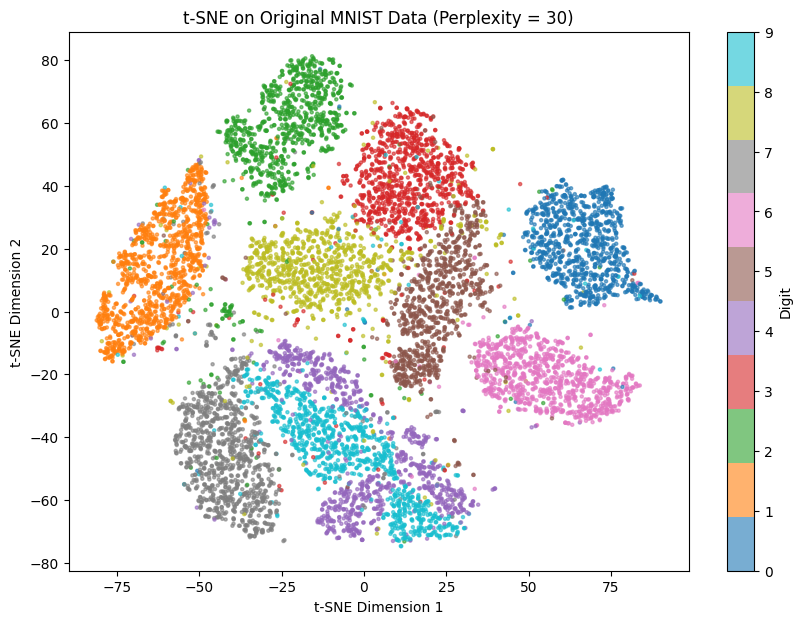

In [ ]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_tsne_original_2d[:, 0],
    X_tsne_original_2d[:, 1],
    c=y_tsne,
    cmap='tab10',
    s=5,
    alpha=0.6
)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("t-SNE on Original MNIST Data (Perplexity = 30)")

plt.colorbar(scatter, label="Digit")

plt.show()

In [ ]:
print("Running t-SNE on PCA-reduced 50-dimensional data...")

start_time = time.time()

tsne_pca = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init='pca',
    learning_rate='auto'
)

X_tsne_pca_2d = tsne_pca.fit_transform(
    X_tsne_pca50
)

tsne_pca_time = time.time() - start_time

print(
    "t-SNE completed in",
    round(tsne_pca_time, 2),
    "seconds"
)

Running t-SNE on PCA-reduced 50-dimensional data...
t-SNE completed in 150.54 seconds


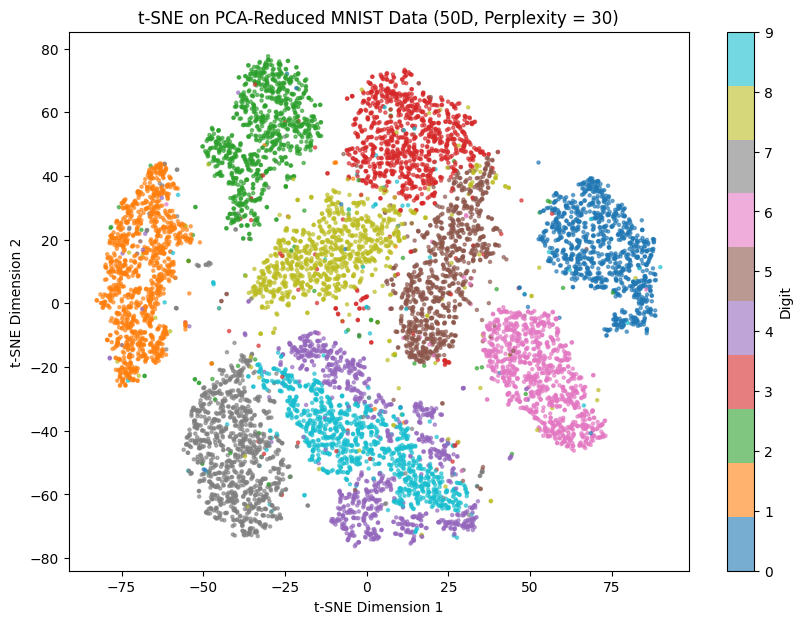

In [ ]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_tsne_pca_2d[:, 0],
    X_tsne_pca_2d[:, 1],
    c=y_tsne,
    cmap='tab10',
    s=5,
    alpha=0.6
)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("t-SNE on PCA-Reduced MNIST Data (50D, Perplexity = 30)")

plt.colorbar(scatter, label="Digit")

plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 56000
Testing samples: 14000


In [ ]:
pca_classifier = PCA(
    n_components=50,
    svd_solver='randomized',
    random_state=42
)

X_train_pca50 = pca_classifier.fit_transform(X_train)
X_test_pca50 = pca_classifier.transform(X_test)

print("Original training shape:", X_train.shape)
print("PCA training shape:", X_train_pca50.shape)

print("Original testing shape:", X_test.shape)
print("PCA testing shape:", X_test_pca50.shape)

Original training shape: (56000, 784)
PCA training shape: (56000, 50)
Original testing shape: (14000, 784)
PCA testing shape: (14000, 50)


In [ ]:
knn_original = KNeighborsClassifier(
    n_neighbors=3,
    n_jobs=-1
)

start_time = time.time()

knn_original.fit(
    X_train,
    y_train
)

original_training_time = time.time() - start_time

print(
    "Original data training time:",
    round(original_training_time, 4),
    "seconds"
)

Original data training time: 0.027 seconds


In [ ]:
start_time = time.time()

y_pred_original = knn_original.predict(X_test)

original_prediction_time = time.time() - start_time

original_accuracy = accuracy_score(
    y_test,
    y_pred_original
)

print(
    "Original data accuracy:",
    round(original_accuracy * 100, 2),
    "%"
)

print(
    "Original data prediction time:",
    round(original_prediction_time, 4),
    "seconds"
)

Original data accuracy: 97.14 %
Original data prediction time: 70.5835 seconds


In [ ]:
knn_pca = KNeighborsClassifier(
    n_neighbors=3,
    n_jobs=-1
)

start_time = time.time()

knn_pca.fit(
    X_train_pca50,
    y_train
)

pca_training_time = time.time() - start_time

print(
    "PCA data training time:",
    round(pca_training_time, 4),
    "seconds"
)

PCA data training time: 0.0078 seconds


In [ ]:
start_time = time.time()

y_pred_pca = knn_pca.predict(
    X_test_pca50
)

pca_prediction_time = time.time() - start_time

pca_accuracy = accuracy_score(
    y_test,
    y_pred_pca
)

print(
    "PCA 50D accuracy:",
    round(pca_accuracy * 100, 2),
    "%"
)

print(
    "PCA 50D prediction time:",
    round(pca_prediction_time, 4),
    "seconds"
)

PCA 50D accuracy: 97.8 %
PCA 50D prediction time: 20.0071 seconds


In [ ]:
comparison = pd.DataFrame({
    "Method": [
        "Original 784D",
        "PCA 50D"
    ],

    "Dimensions": [
        784,
        50
    ],

    "Accuracy (%)": [
        original_accuracy * 100,
        pca_accuracy * 100
    ],

    "Training Time (seconds)": [
        original_training_time,
        pca_training_time
    ],

    "Prediction Time (seconds)": [
        original_prediction_time,
        pca_prediction_time
    ]
})

comparison

,Method,Dimensions,Accuracy (%),Training Time (seconds),Prediction Time (seconds)
0,Original 784D,784,97.142857,0.026975,70.583498
1,PCA 50D,50,97.800000,0.007788,20.007119


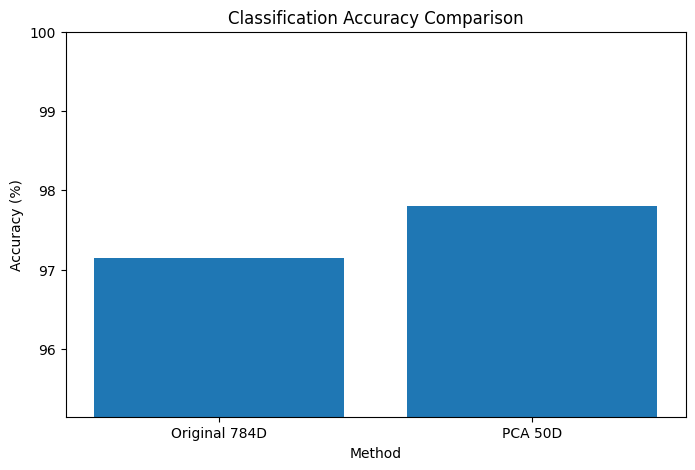

In [ ]:
plt.figure(figsize=(8, 5))

methods = ["Original 784D", "PCA 50D"]
accuracies = [
    original_accuracy * 100,
    pca_accuracy * 100
]

plt.bar(methods, accuracies)

plt.ylabel("Accuracy (%)")
plt.xlabel("Method")
plt.title("Classification Accuracy Comparison")

plt.ylim(
    min(accuracies) - 2,
    100
)

plt.show()

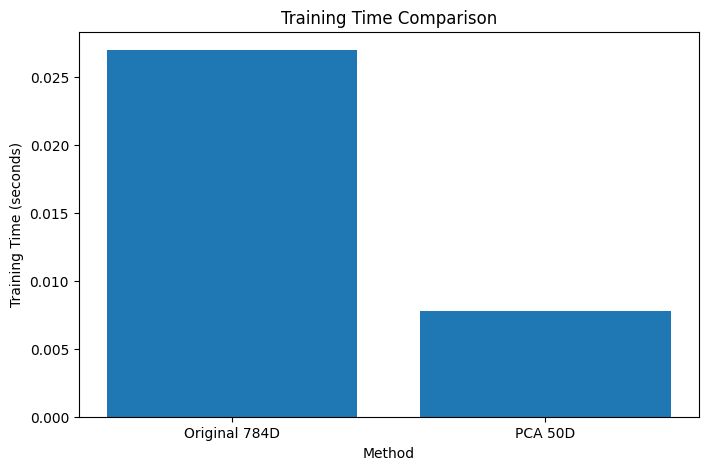

In [ ]:
plt.figure(figsize=(8, 5))

training_times = [
    original_training_time,
    pca_training_time
]

plt.bar(methods, training_times)

plt.ylabel("Training Time (seconds)")
plt.xlabel("Method")
plt.title("Training Time Comparison")

plt.show()

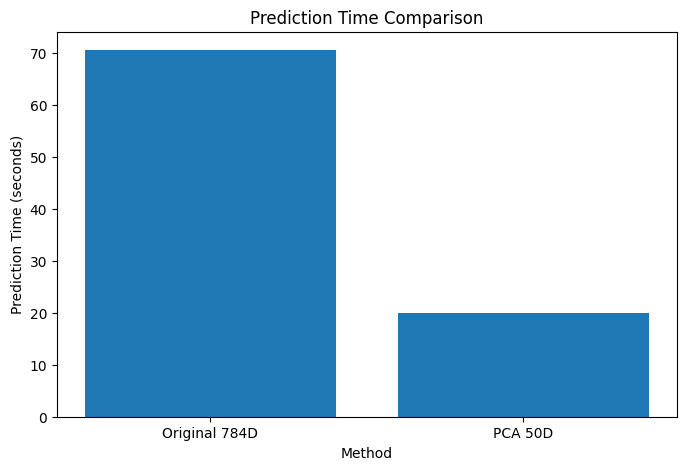

In [ ]:
plt.figure(figsize=(8, 5))

prediction_times = [
    original_prediction_time,
    pca_prediction_time
]

plt.bar(methods, prediction_times)

plt.ylabel("Prediction Time (seconds)")
plt.xlabel("Method")
plt.title("Prediction Time Comparison")

plt.show()

In [ ]:
print("========== FINAL ANALYSIS ==========")

print(f"Original dimensions: {X.shape[1]}")
print(f"PCA dimensions: {X_pca.shape[1]}")

print(f"\nComponents for 90% variance: {n_90}")
print(f"Components for 95% variance: {n_95}")
print(f"Components for 99% variance: {n_99}")

print("\nClassification Results:")
print(
    f"Original 784D Accuracy: "
    f"{original_accuracy * 100:.2f}%"
)

print(
    f"PCA 50D Accuracy: "
    f"{pca_accuracy * 100:.2f}%"
)

print(
    f"\nOriginal Prediction Time: "
    f"{original_prediction_time:.4f} seconds"
)

print(
    f"PCA Prediction Time: "
    f"{pca_prediction_time:.4f} seconds"
)

========== FINAL ANALYSIS ==========
Original dimensions: 784
PCA dimensions: 331

Components for 90% variance: 87
Components for 95% variance: 154
Components for 99% variance: 331

Classification Results:
Original 784D Accuracy: 97.14%
PCA 50D Accuracy: 97.80%

Original Prediction Time: 70.5835 seconds
PCA Prediction Time: 20.0071 seconds
